In [1]:
import os 
import pandas as pd
import re
from pathlib import Path
import numpy as np
from datetime import datetime, timezone
import json

dirs = {
    "instruments_root": r"/Volumes/lab-windingm/data/instruments/behavioural_rigs/plugcamera/mechanosensory-screen/pupae",
    "shared_root" :r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data",
    "local_root": r"/Users/meryv/repos/behavioural-rigs",

    "final-sheets": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/final-sheets", #these are view only
    "intermediate-sheets": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/intermediate-sheets", #these are not completed yet
    
    "mechano-screen" : r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/mechano-screen", #these are edited manually
    "split-screen" : r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/split-screen", 
    
    "backup-mechano": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/mechano-backup", #these are never touched 
    "backup-split": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/split-backup", 

    "plugcamera": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/plugcamera", #not used here
    "notebooks": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/notebooks", 
    
    "fly-lines": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/fly-lines" #sometimes gets updated on Dropbox
}


def read_pupae_counts(experiment_name, nemo_root=dirs["instruments_root"]):
    predictions_dir = Path(nemo_root) / experiment_name / "pupae" / "predictions"

    if not predictions_dir.exists():
        raise FileNotFoundError(f"Predictions folder not found: {predictions_dir}")
    if not predictions_dir.is_dir():
        raise NotADirectoryError(f"Predictions path is not a folder: {predictions_dir}")

    csv_files = sorted(predictions_dir.glob("*.csv"))

    if len(csv_files) == 0:
        raise FileNotFoundError(f"No CSV files found in: {predictions_dir}")

    return pd.read_csv(csv_files[0])

def convert_pupae_date_to_datetime(df_pupae, year):
    df_pupae = df_pupae.copy()
    df_pupae["date"] = df_pupae["date"].astype("string").str.strip()
    date_norm = df_pupae["date"].str.replace("_", "-", regex=False)
    date_full = date_norm + f"-{year}"
    df_pupae["date"] = pd.to_datetime(date_full, format="%d-%m-%Y", errors="coerce")

    return df_pupae

Load condition list with mapping

In [2]:
file_path = Path(dirs["fly-lines"]) / "2026-03-11_mechano-conditions_mapping.csv"

mechano_cond_mapping = pd.read_csv(file_path)

mechano_cond_mapping.columns = mechano_cond_mapping.columns.str.strip()

mechano_cond_mapping["condition"] = (
    mechano_cond_mapping["condition"] 
        .astype("string")      
        .str.strip()           
        .str.lower()   
)
mechano_cond_mapping["condition_2"] = (
    mechano_cond_mapping["condition_2"] 
        .astype("string")      
        .str.strip()           
        .str.lower()   
)

mechano_list = mechano_cond_mapping["condition"].dropna().unique().tolist() #83 conditions
mechano_list_2 = mechano_cond_mapping["condition_2"].dropna().unique().tolist() #56 conditions



In [3]:
df_expected = pd.DataFrame({
    "condition": np.repeat(mechano_list_2, 18), 
    "amendments": 0
})

df_expected["amendments"] = pd.to_numeric(df_expected["amendments"], errors="coerce")
df_expected_2 = df_expected.merge(mechano_cond_mapping, on="condition", how="inner")

exp_plan = (
    df_expected_2.groupby("condition_2", dropna=False)["amendments"]
      .first()
      .reset_index()
)
exp_plan["pct_complete"] = np.where(
    exp_plan["amendments"] == 0, 100,
    np.where(exp_plan["amendments"] == -1, 0, np.nan)
)


In [4]:
#Actual experiments 
file_path = Path(dirs["mechano-screen"])

files = sorted(
    f for f in file_path.glob("*.xlsx")
    if not f.name.startswith("~$")
)

dfs = []

for f in files:
    try:
        tmp = pd.read_excel(f, dtype=str, engine="openpyxl")
        tmp = tmp.dropna(how="all")
        tmp.columns = tmp.columns.str.strip()

        tmp["source_file"] = f.name
        tmp["experiment_name"] = f.stem

        dfs.append(tmp)

    except Exception as e:
        print(f"Skipping {f.name}: {e}")

df_actual = pd.concat(dfs, ignore_index=True)

df_actual["amendments"] = pd.to_numeric(df_actual["amendments"], errors="coerce")
df_actual["amendments"] = df_actual["amendments"].fillna(0).astype(int)

df_actual["condition"] = (
    df_actual["condition"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df_actual


,experimenter,collector,incubator,shelf,rack,plugcamera,condition,location,staging_date,amendments,...,pupae_batch_folder,last_edit,Other name,source_file,experiment_name,condition_comments,condition_comment,pupae_batch_folder.1,Unnamed: 42,pupae notes
0,LK,HS,1,2,1,73,ss25755,NaN,13-14/01/2026,0,...,2026-01-28_LK_mechano-week1_batch3,2026-02-05T13:33:45.876643+00:00,NaN,2026-01-05_mechano-screen_week-1.xlsx,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN
1,LK,HS,1,2,1,74,ss04330,NaN,13-14/01/2026,0,...,VM_2026-01-30_LK_mechano-week1-week2_batch5,2026-02-05T13:33:45.876643+00:00,NaN,2026-01-05_mechano-screen_week-1.xlsx,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN
2,LK,HS,1,2,1,75,49826,NaN,13-14/01/2026,-1,...,VM_2026-02-02_mechano-week-1_manual,2026-02-05T13:33:45.876643+00:00,NaN,2026-01-05_mechano-screen_week-1.xlsx,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN
3,LK,HS,1,2,1,76,ss55086,NaN,13-14/01/2026,0,...,2026-01-28_LK_mechano-week1_batch3,2026-02-05T13:33:45.876643+00:00,NaN,2026-01-05_mechano-screen_week-1.xlsx,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN
4,LK,HS,1,2,1,96,ss03767,NaN,13-14/01/2026,-1,...,VM_2026-02-02_mechano-week-2_batch6_f14,2026-02-05T13:33:45.876643+00:00,NaN,2026-01-05_mechano-screen_week-1.xlsx,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,NaN,NaN,NaN,NaN,NaN,209,48877,NaN,2026-03-20 00:00:00,0,...,NaN,NaN,NaN,2026-03-09_mechano-screen_week-10.xlsx,2026-03-09_mechano-screen_week-10,NaN,NaN,NaN,NaN,VM_2026-04-01_mechano-week-10_batch3_f26
2246,NaN,NaN,NaN,NaN,NaN,210,49766,NaN,2026-03-20 00:00:00,-1,...,NaN,NaN,NaN,2026-03-09_mechano-screen_week-10.xlsx,2026-03-09_mechano-screen_week-10,NaN,NaN,NaN,NaN,VM_2026-04-01_mechano-week-10_manual_f13
2247,NaN,NaN,NaN,NaN,NaN,211,73947,NaN,2026-03-20 00:00:00,-1,...,NaN,NaN,NaN,2026-03-09_mechano-screen_week-10.xlsx,2026-03-09_mechano-screen_week-10,NaN,NaN,NaN,NaN,VM_2026-04-01_mechano-week-10_manual_f13
2248,NaN,NaN,NaN,NaN,NaN,212,ss00911,NaN,2026-03-20 00:00:00,-1,...,NaN,NaN,NaN,2026-03-09_mechano-screen_week-10.xlsx,2026-03-09_mechano-screen_week-10,NaN,NaN,NaN,NaN,VM_2026-04-01_mechano-week-10_batch3_f26


In [41]:
m = mechano_cond_mapping.copy()
m["condition_norm"] = m["condition"].astype(str).str.strip()

dupe_rows = m[m["condition_norm"].duplicated(keep=False)] \
    .sort_values("condition_norm")

dupe_rows

,condition,condition_2,mapping,condition_comments,condition_norm


In [42]:
df_actual_mapped = df_actual.merge(
    mechano_cond_mapping, 
    on="condition", how="left", validate="m:1"
    )

df_actual_mapped = df_actual_mapped.rename(columns={"condition" :"og_condition"})

In [43]:
df_final = df_actual_mapped.copy()
df_final.columns = df_final.columns.str.strip()
df_final = df_final.rename(columns={"condition_2": "condition"})

df_final["amendments"] = (
    df_final["amendments"]
        .astype("string")      # treat everything consistently
        .str.strip()           # remove whitespace
        .replace("", pd.NA)    # empty strings -> NA
)

df_final["amendments"] = pd.to_numeric(df_final["amendments"], errors="coerce")
df_final["amendments"] = df_final["amendments"].fillna(-1).astype(int)

am = (
    df_final["amendments"]
    .astype("string")
    .str.strip()
    .replace("", "not_done")
)

df_final["amendments_num"] = pd.to_numeric(am, errors="coerce")
df_final["amendments_num"].value_counts()

amendments_num
0     1160
-1    1089
1        1
Name: count, dtype: Int64

In [44]:
successful_counts = (
    df_final.groupby("condition")["amendments_num"]
    .agg(
        successful=lambda x: (x == 0).sum(),
        failed=lambda x: (x == -1).sum()
    )
    .reset_index()
)
len(successful_counts)

successful_counts["total_completed"] = (
    successful_counts["successful"] +
    successful_counts["failed"]
)

successful_counts["expected_successful"] = 18

successful_counts["ready"] = np.where(
    successful_counts["successful"] >= successful_counts["expected_successful"], 
    "yes", 
    "no"
)

#successful_counts.to_csv("2026-02-19_successful-counts.csv")
#successful_counts_ordered = successful_counts.sort_values("left_to_do", ascending=False).reset_index(drop=True)
#successful_counts_ordered.to_csv("2026-02-19_successful-exp-ordered.csv")

successful_counts

,condition,successful,failed,total_completed,expected_successful,ready
0,19-12-gal4,2,70,72,18,no
1,26259,12,30,42,18,no
2,45873,19,17,36,18,yes
3,48877,25,11,36,18,yes
4,49766,14,34,48,18,no
5,49826,2,58,60,18,no
6,49828,16,38,54,18,no
7,50377,20,28,48,18,yes
8,57618,25,11,36,18,yes
9,602023,23,13,36,18,yes


In [45]:
import matplotlib.pyplot as plt
import numpy as np

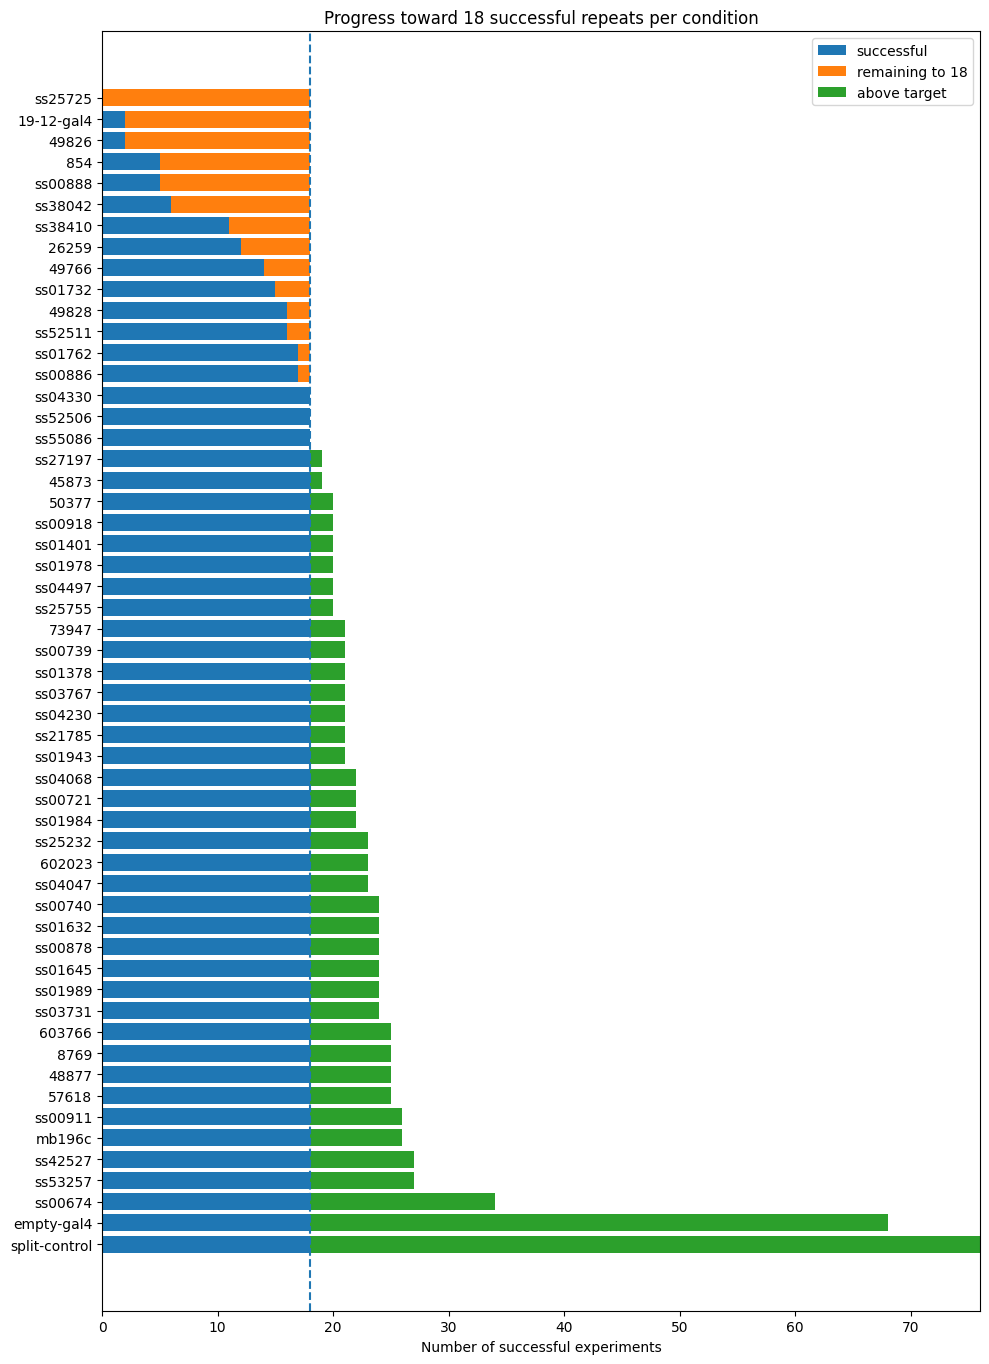

In [46]:


# Build plotting table
plot_df = successful_counts.copy()
plot_df["remaining_successes"] = (plot_df["expected_successful"] - plot_df["successful"]).clip(lower=0)
plot_df["over_target"] = (plot_df["successful"] - plot_df["expected_successful"]).clip(lower=0)

# Sort: most incomplete at top
plot_df = plot_df.sort_values(["successful", "failed"], ascending=[True, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(plot_df) * 0.25)))

y = np.arange(len(plot_df))

ax.barh(y, plot_df["successful"], label="successful")
ax.barh(y, plot_df["remaining_successes"], left=plot_df["successful"], label="remaining to 18")
ax.barh(y, plot_df["over_target"], left=plot_df["expected_successful"], label="above target")

ax.set_yticks(y)
ax.set_yticklabels(plot_df["condition"])
ax.set_xlabel("Number of successful experiments")
ax.set_title("Progress toward 18 successful repeats per condition")
ax.axvline(18, linestyle="--")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

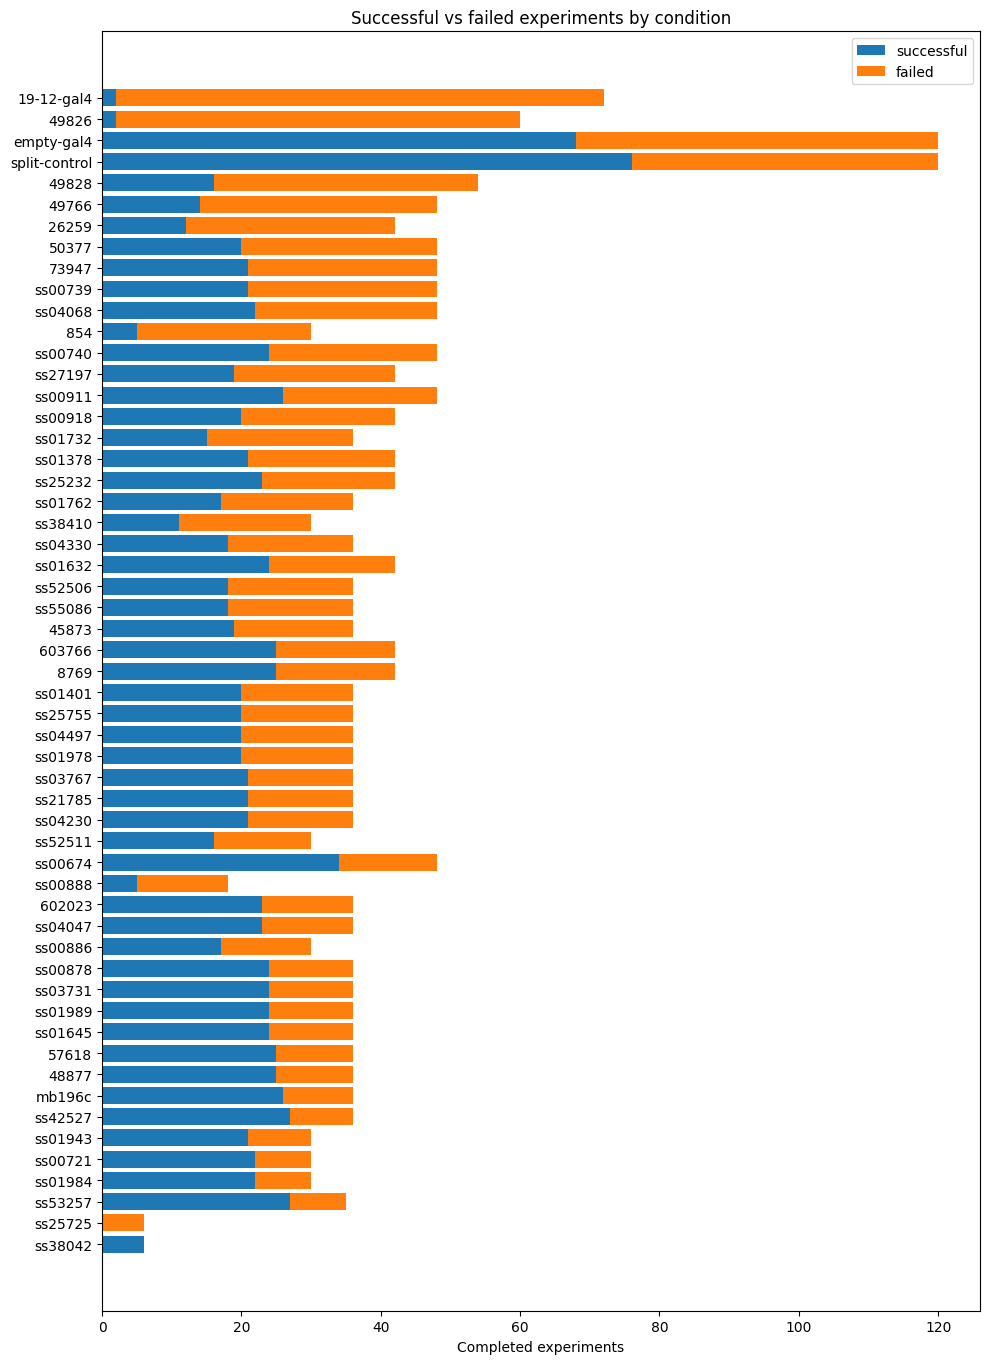

In [47]:
plot_df2 = successful_counts.copy()
plot_df2 = plot_df2.sort_values("failed", ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(plot_df2) * 0.25)))

y = np.arange(len(plot_df2))

ax.barh(y, plot_df2["successful"], label="successful")
ax.barh(y, plot_df2["failed"], left=plot_df2["successful"], label="failed")

ax.set_yticks(y)
ax.set_yticklabels(plot_df2["condition"])
ax.set_xlabel("Completed experiments")
ax.set_title("Successful vs failed experiments by condition")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

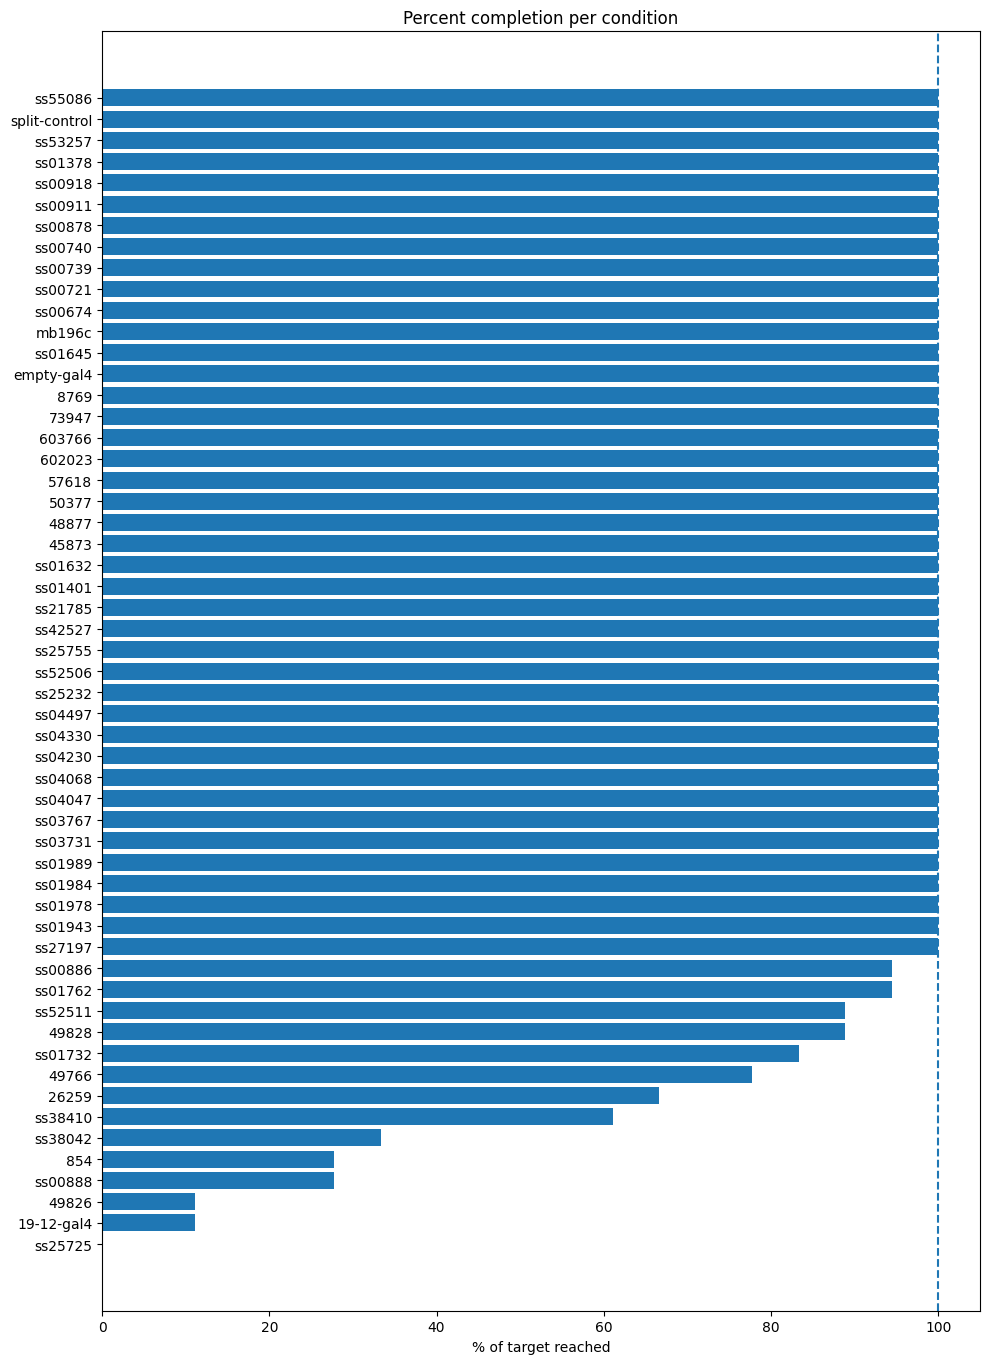

In [48]:
plot_df3 = successful_counts.copy()
plot_df3["pct_success_target"] = 100 * plot_df3["successful"] / plot_df3["expected_successful"]
plot_df3["pct_success_target"] = plot_df3["pct_success_target"].clip(upper=100)
plot_df3 = plot_df3.sort_values("pct_success_target", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(plot_df3) * 0.25)))

ax.barh(plot_df3["condition"], plot_df3["pct_success_target"])
ax.set_xlabel("% of target reached")
ax.set_title("Percent completion per condition")
ax.axvline(100, linestyle="--")
plt.tight_layout()
plt.show()

In [49]:
n_conditions = successful_counts["condition"].nunique()
n_ready = (successful_counts["ready"] == "yes").sum()
total_successful = successful_counts["successful"].sum()
total_failed = successful_counts["failed"].sum()
target_total = successful_counts["expected_successful"].sum()

overall_pct = 100 * total_successful / target_total if target_total else np.nan

print(f"Conditions: {n_conditions}")
print(f"Ready conditions: {n_ready}")
print(f"Successful experiments: {total_successful}")
print(f"Failed experiments: {total_failed}")
print(f"Overall completion: {overall_pct:.1f}%")

Conditions: 55
Ready conditions: 41
Successful experiments: 1160
Failed experiments: 1089
Overall completion: 117.2%


In [50]:
unfinished_lines = successful_counts.loc[
    successful_counts["successful"] < successful_counts["expected_successful"],
    "condition"
].dropna().unique().tolist()

len(unfinished_lines)

14

In [51]:
df_unfinished = df_final[df_final["condition"].isin(unfinished_lines)].copy()
df_unfinished.shape

(498, 51)

In [ ]:
import pandas as pd
import numpy as np
import re

df_unfinished = df_unfinished.copy()

# Ensure Pupae is numeric
df_unfinished["Pupae"] = pd.to_numeric(df_unfinished["Pupae"], errors="coerce")

# Find health columns automatically
mortality_cols = [c for c in df_unfinished.columns if c.endswith("_mortality_n")]
removed_egg_cols = [c for c in df_unfinished.columns if "removed" in c and "eggs" in c]


['mon_pm_mortality_n',
 'tues_am_mortality_n',
 'tues_pm_mortality_n',
 'weds_am_mortality_n',
 'weds_pm_mortality_n',
 'thurs_am_mortality_n',
 'thurs_pm_mortality_n',
 'fri_am_mortality_n',
 'fri_pm_mortality_n']

In [54]:
def to_binary(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"1", "true", "yes", "y"}:
        return 1
    if s in {"0", "false", "no", "n"}:
        return 0
    if s == "":
        return np.nan
    return pd.to_numeric(s, errors="coerce")

for c in removed_egg_cols:
    df_unfinished[c] = df_unfinished[c].apply(to_binary)

for c in mortality_cols:
    df_unfinished[c] = pd.to_numeric(df_unfinished[c], errors="coerce")

In [55]:
df_unfinished["total_mortality"] = df_unfinished[mortality_cols].sum(axis=1, skipna=True)
df_unfinished["mean_mortality_per_check"] = df_unfinished[mortality_cols].mean(axis=1, skipna=True)

df_unfinished["total_removed_eggs_checks"] = df_unfinished[removed_egg_cols].sum(axis=1, skipna=True)
df_unfinished["mean_removed_eggs_binary"] = df_unfinished[removed_egg_cols].mean(axis=1, skipna=True)

# optional: any removed eggs happened at all in that experiment
df_unfinished["any_removed_eggs"] = np.where(
    df_unfinished["total_removed_eggs_checks"].fillna(0) > 0, 1, 0
)

In [ ]:
health_stats_unfinished = (
    df_unfinished.groupby("condition")
    .agg(
        n_experiments=("condition", "size"),
        avg_pupae=("Pupae", "mean"),
        median_pupae=("Pupae", "median"),
        sd_pupae=("Pupae", "std"),

        avg_total_mortality=("total_mortality", "mean"),
        median_total_mortality=("total_mortality", "median"),
        sum_total_mortality=("total_mortality", "sum"),

        avg_mortality_per_check=("mean_mortality_per_check", "mean"),

        avg_removed_eggs_checks=("total_removed_eggs_checks", "mean"),
        sum_removed_eggs_checks=("total_removed_eggs_checks", "sum"),
        frac_experiments_any_removed_eggs=("any_removed_eggs", "mean"),
        avg_removed_eggs_binary=("mean_removed_eggs_binary", "mean"),
    )
    .reset_index()
)

health_stats_unfinished["avg_pupae"] = health_stats_unfinished["avg_pupae"].round(2)
health_stats_unfinished["median_pupae"] = health_stats_unfinished["median_pupae"].round(2)
health_stats_unfinished["sd_pupae"] = health_stats_unfinished["sd_pupae"].round(2)
health_stats_unfinished["avg_total_mortality"] = health_stats_unfinished["avg_total_mortality"].round(2)
health_stats_unfinished["median_total_mortality"] = health_stats_unfinished["median_total_mortality"].round(2)
health_stats_unfinished["avg_mortality_per_check"] = health_stats_unfinished["avg_mortality_per_check"].round(2)
health_stats_unfinished["avg_removed_eggs_checks"] = health_stats_unfinished["avg_removed_eggs_checks"].round(2)
health_stats_unfinished["frac_experiments_any_removed_eggs"] = (
    100 * health_stats_unfinished["frac_experiments_any_removed_eggs"]
).round(1)
health_stats_unfinished["avg_removed_eggs_binary"] = health_stats_unfinished["avg_removed_eggs_binary"].round(2)

health_stats_unfinished = health_stats_unfinished.sort_values(
    ["avg_total_mortality", "avg_removed_eggs_checks"],
    ascending=False
).reset_index(drop=True)

health_stats_unfinished

remaining_lines = health_stats_unfinished[["condition", "n_experiments", "avg_pupae"]].copy()
#remaining_lines.to_csv("remaining-lines-stats.csv")

Amendments stats

In [89]:
df_final

,experimenter,collector,incubator,shelf,rack,plugcamera,og_condition,location,staging_date,amendments,...,experiment_name,condition_comments_x,condition_comment,pupae_batch_folder.1,Unnamed: 42,pupae notes,condition,mapping,condition_comments_y,amendments_num
0,LK,HS,1,2,1,73,ss25755,NaN,13-14/01/2026,0,...,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN,ss25755,NaN,NaN,0
1,LK,HS,1,2,1,74,ss04330,NaN,13-14/01/2026,0,...,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN,ss04330,NaN,NaN,0
2,LK,HS,1,2,1,75,49826,NaN,13-14/01/2026,-1,...,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN,49826,NaN,NaN,-1
3,LK,HS,1,2,1,76,ss55086,NaN,13-14/01/2026,0,...,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN,ss55086,NaN,NaN,0
4,LK,HS,1,2,1,96,ss03767,NaN,13-14/01/2026,-1,...,2026-01-05_mechano-screen_week-1,NaN,NaN,NaN,NaN,NaN,ss03767,NaN,NaN,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,NaN,NaN,NaN,NaN,NaN,209,48877,NaN,2026-03-20 00:00:00,0,...,2026-03-09_mechano-screen_week-10,NaN,NaN,NaN,NaN,VM_2026-04-01_mechano-week-10_batch3_f26,48877,NaN,NaN,0
2246,NaN,NaN,NaN,NaN,NaN,210,49766,NaN,2026-03-20 00:00:00,-1,...,2026-03-09_mechano-screen_week-10,NaN,NaN,NaN,NaN,VM_2026-04-01_mechano-week-10_manual_f13,49766,NaN,NaN,-1
2247,NaN,NaN,NaN,NaN,NaN,211,73947,NaN,2026-03-20 00:00:00,-1,...,2026-03-09_mechano-screen_week-10,NaN,NaN,NaN,NaN,VM_2026-04-01_mechano-week-10_manual_f13,73947,NaN,NaN,-1
2248,NaN,NaN,NaN,NaN,NaN,212,ss00911,NaN,2026-03-20 00:00:00,-1,...,2026-03-09_mechano-screen_week-10,NaN,NaN,NaN,NaN,VM_2026-04-01_mechano-week-10_batch3_f26,ss00911,NaN,NaN,-1


In [5]:
raw_comment_counts = pd.read_csv("raw_comment_counts.csv")
raw_comment_counts

,Unnamed: 0,comment,n,comment_clean
0,0,not enough pupae,400,not enough pupae
1,1,no pupae rec,59,pupae rec missing
2,2,camera issue,42,camera issue
3,3,pupae count likely failed,29,pupae rec missing
4,4,no pupae,25,not enough pupae
...,...,...,...,...
257,257,"camera issue, check folder. Only 9 images",1,camera issue
258,258,"camera issue, no data folder",1,camera issue
259,259,"says permission denied but folder is working, ...",1,general pi issue
260,260,"not enough pupae; resolved IP address issue, c...",1,not enough pupae


0                                  NaN
1                                  NaN
2                   pupae count failed
3          High death over the weekend
4                             Too many
                     ...              
2245                               NaN
2246    camera issue; not enough pupae
2247                  not enough pupae
2248                    camera issue. 
2249                  not enough pupae
Name: comments, Length: 2250, dtype: object

In [93]:
df_failed = df_final[df_final["amendments_num"] == -1].copy()

df_failed2 = df_failed.merge(
    raw_comment_counts,
    left_on="comments",
    right_on="comment",
    how="inner"
)

In [94]:
df_failed2

,experimenter,collector,incubator,shelf,rack,plugcamera,og_condition,location,staging_date,amendments,...,Unnamed: 42,pupae notes,condition,mapping,condition_comments_y,amendments_num,Unnamed: 0,comment,n,comment_clean
0,LK,HS,1,2,1,75,49826,NaN,13-14/01/2026,-1,...,NaN,NaN,49826,NaN,NaN,-1,143,pupae count failed,1,pupae rec missing
1,LK,HS,1,2,1,96,ss03767,NaN,13-14/01/2026,-1,...,NaN,NaN,ss03767,NaN,NaN,-1,9,Too many,18,too many pupae
2,LK,HS,1,2,1,80,854,NaN,13-14/01/2026,-1,...,NaN,NaN,854,NaN,Leave more eggs than expected - seems like not...,-1,25,"<100, can't count strong phenotype",5,not enough pupae
3,LK,HS,1,2,1,84,50377,NaN,13-14/01/2026,-1,...,NaN,NaN,50377,NaN,NaN,-1,3,pupae count likely failed,29,pupae rec missing
4,LK,HS,1,2,1,87,ss01978,NaN,13-14/01/2026,-1,...,NaN,NaN,ss01978,NaN,NaN,-1,3,pupae count likely failed,29,pupae rec missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043,NaN,NaN,NaN,NaN,NaN,207,ss03731,NaN,2026-03-20 00:00:00,-1,...,NaN,n/d,ss03731,NaN,NaN,-1,0,not enough pupae,400,not enough pupae
1044,NaN,NaN,NaN,NaN,NaN,208,45873,NaN,2026-03-20 00:00:00,-1,...,NaN,manual,45873,NaN,NaN,-1,0,not enough pupae,400,not enough pupae
1045,NaN,NaN,NaN,NaN,NaN,210,49766,NaN,2026-03-20 00:00:00,-1,...,NaN,VM_2026-04-01_mechano-week-10_manual_f13,49766,NaN,NaN,-1,10,camera issue; not enough pupae,15,camera issue
1046,NaN,NaN,NaN,NaN,NaN,211,73947,NaN,2026-03-20 00:00:00,-1,...,NaN,VM_2026-04-01_mechano-week-10_manual_f13,73947,NaN,NaN,-1,0,not enough pupae,400,not enough pupae


In [107]:
comment_clean_counts = (
    df_failed2["comment_clean"]
    .value_counts(dropna=False)
    .reset_index()
)
comment_clean_counts.columns = ["comment_clean", "n"]

comment_clean_counts

,comment_clean,n
0,not enough pupae,506
1,camera issue,130
2,pupae rec missing,126
3,ssh issue,74
4,too many pupae,66
5,video issue,51
6,script issue,51
7,general pi issue,25
8,connection issue,8
9,pupae rec duplicate,8


In [108]:
comment_clean_counts_total = pd.concat([
    comment_clean_counts,
    pd.DataFrame({
        "comment_clean": ["TOTAL"],
        "n": [comment_clean_counts["n"].sum()]
    })
], ignore_index=True)

comment_clean_counts_total

,comment_clean,n
0,not enough pupae,506
1,camera issue,130
2,pupae rec missing,126
3,ssh issue,74
4,too many pupae,66
5,video issue,51
6,script issue,51
7,general pi issue,25
8,connection issue,8
9,pupae rec duplicate,8


In [110]:
df_failed2["comment_clean"] = (
    df_failed2["comment_clean"]
    .astype("string")
    .str.strip()
)

df_failed2["comment_clean"] = df_failed2["comment_clean"].fillna("unknown")
df_failed2.loc[df_failed2["comment_clean"] == "", "comment_clean"] = "unknown"

In [113]:
comment_clean_counts = (
    df_failed2["comment_clean"]
    .value_counts(dropna=False)
    .reset_index()
)
comment_clean_counts.columns = ["comment_clean", "n"]

comment_clean_counts

,comment_clean,n
0,not enough pupae,506
1,camera issue,130
2,pupae rec missing,126
3,ssh issue,74
4,too many pupae,66
5,video issue,51
6,script issue,51
7,general pi issue,25
8,connection issue,8
9,pupae rec duplicate,8


In [101]:
condition_comment_counts = (
    df_failed2.groupby(["condition", "comment_clean"])
    .size()
    .reset_index(name="n")
    .sort_values(["condition", "n"], ascending=[True, False])
)


In [ ]:
# summary of mapped errors
comment_clean_counts = (
    df_failed2["comment_clean"]
    .fillna("unmapped")
    .value_counts()
    .reset_index()
)
comment_clean_counts.columns = ["comment_clean", "n"]

# condition x mapped error
condition_comment_counts = (
    df_failed2.groupby(["condition", "comment_clean"])
    .size()
    .reset_index(name="n")
    .sort_values(["condition", "n"], ascending=[True, False])
)

comment_clean_counts.head(20)
condition_comment_counts.to_csv("condition-errors.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df_failed["condition"] = (
    df_failed["condition"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df_failed["comments"] = (
    df_failed["comments"]
    .astype("string")
    .fillna("")
    .str.strip()
)

raw_comment_counts = (
    df_failed["comments"]
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .reset_index()
)
raw_comment_counts.columns = ["comment", "n"]

#raw_comment_counts.to_csv("raw_comment_counts.csv")

In [ ]:
df_failed = df_final[df_final["amendments_num"] == -1].copy()

# check columns
print(df_failed.columns.tolist())

# summary of mapped errors
comment_clean_counts = (
    df_failed["comment_clean"]
    .fillna("unmapped")
    .value_counts()
    .reset_index()
)
comment_clean_counts.columns = ["comment_clean", "n"]

# condition x mapped error
condition_comment_counts = (
    df_failed.groupby(["condition", "comment_clean"])
    .size()
    .reset_index(name="n")
    .sort_values(["condition", "n"], ascending=[True, False])
)

comment_clean_counts.head(20)
condition_comment_counts.head(20)

,Unnamed: 0,comment,n,comment_clean
0,0,not enough pupae,400,not enough pupae
1,1,no pupae rec,59,pupae rec missing
2,2,camera issue,42,camera issue
3,3,pupae count likely failed,29,pupae rec missing
4,4,no pupae,25,not enough pupae
...,...,...,...,...
257,257,"camera issue, check folder. Only 9 images",1,camera issue
258,258,"camera issue, no data folder",1,camera issue
259,259,"says permission denied but folder is working, ...",1,general pi issue
260,260,"not enough pupae; resolved IP address issue, c...",1,not enough pupae


In [74]:
def normalize_comment(text):
    if pd.isna(text):
        return pd.NA
    
    s = str(text).strip().lower()
    if s == "":
        return pd.NA
    
    # standardize common variants
    replacements = {
        r"\bcam\b": "pi issue",
        r"\bplug camera\b": "pi issue",
        r"\bnot enough pupae\b": "pupae number",
        r"\bssh\b": "ssh",
        r"\bnot recorded\b": "pupae number",
        r"\bno pupae rec\b": "pupae number",
        r"\btoo many\b": "pupae number",
        r"\bpupae\b": "pupae number",
        r"\bscript\b": "pi issue",
        r"\bstrong phenotype\b": "pupae number",
        r"\bunsure\b": "pi issue",
        r"\brecordings\b": "pi issue",
        r"\bimages\b": "pi issue",
    }
    
    for pattern, repl in replacements.items():
        s = re.sub(pattern, repl, s)
    
    # remove punctuation
    s = re.sub(r"[^\w\s]", " ", s)
    # collapse spaces
    s = re.sub(r"\s+", " ", s).strip()
    
    return s if s else pd.NA

df_failed["comment_clean"] = df_failed["comments"].apply(normalize_comment)
df_failed["comment_clean"]

2              pupae number count failed
4                    pupae number number
7           100 can t count pupae number
9                    pupae number number
11      pupae number count likely failed
                      ...               
2244                 pupae number number
2246    camera issue pupae number number
2247                 pupae number number
2248                        camera issue
2249                 pupae number number
Name: comment_clean, Length: 1089, dtype: object

In [76]:
comment_counts = (
    df_failed["comment_clean"]
    .dropna()
    .value_counts()
    .reset_index()
)
comment_counts.columns = ["comment_clean", "n"]

comment_counts

,comment_clean,n
0,pupae number number,479
1,camera issue,47
2,pupae number count likely failed,29
3,no pupae number,25
4,pupae number number pupae number,23
...,...,...
234,remote host identification,1
235,memory issue pupae number number,1
236,pupae number number only 4 pi issue,1
237,no data folder,1


In [77]:
failed_by_condition = (
    df_failed.groupby("condition")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_failed")
)

failed_by_condition.head(20)

,condition,n_failed
0,19-12-gal4,70
1,49826,58
2,empty-gal4,52
3,split-control,44
4,49828,38
5,49766,34
6,26259,30
7,50377,28
8,73947,27
9,ss00739,27


In [79]:
condition_totals = (
    df_final.groupby("condition")
    .size()
    .reset_index(name="n_total")
)

condition_fails = (
    df_failed.groupby("condition")
    .size()
    .reset_index(name="n_failed")
)

condition_error_stats = condition_totals.merge(condition_fails, on="condition", how="left")
condition_error_stats["n_failed"] = condition_error_stats["n_failed"].fillna(0).astype(int)
condition_error_stats["failure_rate"] = condition_error_stats["n_failed"] / condition_error_stats["n_total"]

condition_error_stats = condition_error_stats.sort_values("failure_rate", ascending=False)
condition_error_stats.head(20)

,condition,n_total,n_failed,failure_rate
45,ss25725,6,6,1.000000
0,19-12-gal4,72,70,0.972222
5,49826,60,58,0.966667
12,854,30,25,0.833333
23,ss00888,18,13,0.722222
1,26259,42,30,0.714286
4,49766,48,34,0.708333
6,49828,54,38,0.703704
49,ss38410,30,19,0.633333
7,50377,48,28,0.583333


In [81]:
comment_condition_table = (
    df_failed.dropna(subset=["comment_clean"])
    .groupby(["condition", "comment_clean"])
    .size()
    .reset_index(name="n")
)
comment_condition_table

,condition,comment_clean,n
0,19-12-gal4,camera,1
1,19-12-gal4,camera issue,1
2,19-12-gal4,camera issue pupae number number,1
3,19-12-gal4,camera timeout pupae number number,1
4,19-12-gal4,leave more eggs than expected seems like not v...,1
...,...,...,...
546,ss55086,cannot start pi issue due to rig_num error,1
547,ss55086,note duplicate pupae number number,1
548,ss55086,pupae number number,11
549,ss55086,pupae number number not counted,2


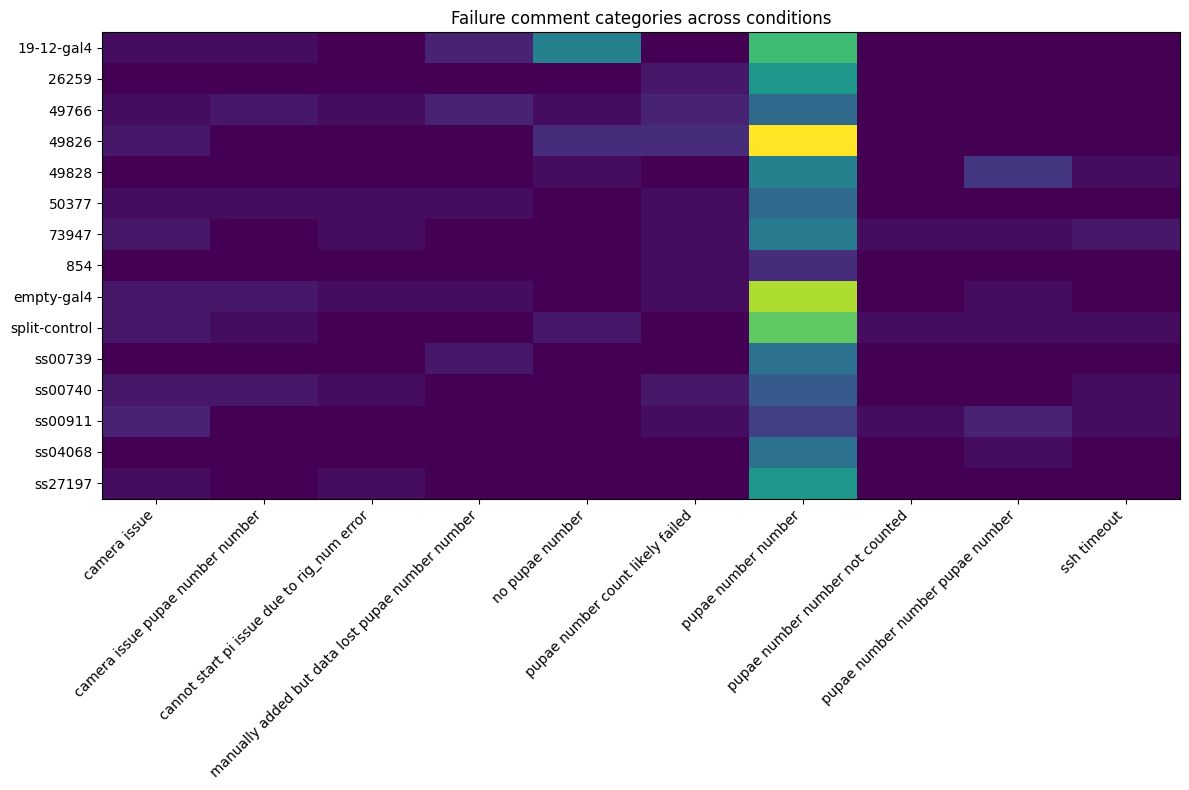

In [83]:
top_n_comments = 10
top_n_conditions = 15

top_comment_labels = comment_counts.head(top_n_comments)["comment_clean"].tolist()
top_condition_labels = failed_by_condition.head(top_n_conditions)["condition"].tolist()

heat_df = comment_condition_table[
    comment_condition_table["comment_clean"].isin(top_comment_labels) &
    comment_condition_table["condition"].isin(top_condition_labels)
].copy()

heat_pivot = heat_df.pivot(
    index="condition",
    columns="comment_clean",
    values="n"
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat_pivot.values, aspect="auto", interpolation="nearest")

ax.set_xticks(np.arange(len(heat_pivot.columns)))
ax.set_xticklabels(heat_pivot.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heat_pivot.index)))
ax.set_yticklabels(heat_pivot.index)

ax.set_title("Failure comment categories across conditions")
plt.tight_layout()
plt.show()

Adding intermediate sheets

In [9]:
file_path = Path(dirs["intermediate-sheets"])

files = sorted(
    f for f in file_path.glob("*csv")
    if not f.name.startswith("~$")
)

dfs = []

for f in files:
    try:
        tmp = pd.read_csv(f)
        tmp = tmp.dropna(how="all")
        tmp.columns = tmp.columns.str.strip()

        tmp["source_file"] = f.name
        tmp["experiment_name"] = f.stem

        dfs.append(tmp)

    except Exception as e:
        print(f"Skipping {f.name}: {e}")

df_intermediate  = pd.concat(dfs, ignore_index=True)
df_intermediate.columns = df_intermediate.columns.str.strip()

df_intermediate["condition"] = (
    df_intermediate["condition"] 
        .astype("string")      
        .str.strip()           
        .str.lower()   
)

df_intermediate_mapped = df_intermediate.merge(
    mechano_cond_mapping, 
    on="condition", how="left", validate="m:1"
    )

df_intermediate_mapped = df_intermediate_mapped.rename(columns={"condition" :"og_condition"})

df_intermediate_mapped["amendments"] = (
    df_intermediate_mapped["amendments"]
        .astype("string")      
        .str.strip()           
        .replace("", pd.NA)    
)


df_intermediate_mapped["amendments"] = pd.to_numeric(
    df_intermediate_mapped["amendments"],
    errors="coerce"
)

mask_pending = df_intermediate_mapped["amendments"].isna() | (df_intermediate_mapped["amendments"] != -1)
df_pending = df_intermediate_mapped.loc[mask_pending].copy()

df_pending

ValueError: No objects to concatenate

In [10]:

pending_counts = (
    df_pending.groupby("condition_2")
    .size()
    .reset_index(name="pending")
    .rename(columns={"condition_2": "condition"})
)
successful_counts_wpending = successful_counts.merge(
    pending_counts,
    on="condition",
    how="left"
)


successful_counts_wpending["pending"] = successful_counts_wpending["pending"].fillna(0).astype(int)
successful_counts_wpending["potential_successful"] = successful_counts_wpending["pending"] + successful_counts_wpending["successful"]


successful_counts_wpending = successful_counts_wpending.sort_values("successful", ascending=True).reset_index(drop=True)
successful_counts_wpending

NameError: name 'df_pending' is not defined

In [ ]:
successful_counts_wpending["left_to_do"] = (successful_counts_wpending["expected_successful"] - successful_counts_wpending["potential_successful"])
successful_counts_wpending = successful_counts_wpending.sort_values("left_to_do", ascending=False).reset_index(drop=True)
successful_counts_wpending
#emergency_crosses = successful_counts_wpending.head(12)
#successful_counts_wpending.to_csv("2026-03-18_successful_counts_wpending_update.csv")


Archive

In [ ]:

# Keep only non -1 rows
df_pending = df_intermediate_mapped[
    df_intermediate_mapped["amendments"] != -1
].copy()




In [ ]:
intermediate_final = df_actual_mapped[["plugcamera", "og_condition", "condition_2","staging_date", "amendments", "comments", "staging_times", "Pupae"]].copy()
intermediate_final.columns = df_final.columns.str.strip()
intermediate_final = intermediate_final.rename(columns={"condition_2": "condition"})

df_final["amendments"] = (
    df_final["amendments"]
        .astype("string")      # treat everything consistently
        .str.strip()           # remove whitespace
        .replace("", pd.NA)    # empty strings -> NA
)

df_final["amendments"] = pd.to_numeric(df_final["amendments"], errors="coerce")
df_final["amendments"] = df_final["amendments"].fillna(-1).astype(int)

am = (
    df_final["amendments"]
    .astype("string")
    .str.strip()
    .replace("", "not_done")
)

df_final["amendments_num"] = pd.to_numeric(am, errors="coerce")
df_final["amendments_num"].value_counts()

Archive

In [ ]:
summary = (
    df_expected.groupby("condition", dropna=False)["amendments"]
      .first()
      .reset_index()
)

summary["pct_complete"] = np.where(
    summary["amendments"] == 0, 100,
    np.where(summary["amendments"] == -1, 0, np.nan)
)

summary = summary.sort_values("condition")  # alphabetical

conditions = summary["condition"].tolist()

len(conditions)

In [ ]:
expected_from_template = exp_plan.groupby("condition_2").size().rename("expected_n").reset_index()

expected_n = expected_from_template.merge(
    pd.DataFrame({"condition": df_final["condition"].dropna().unique()}),
    on="condition_2",
    how="outer"
)

Compare expected vs. actual

In [ ]:
expected_n = exp_plan.groupby("condition").size().rename("expected_n").reset_index()
expected_from_template = exp_plan.groupby("condition").size().rename("expected_n").reset_index()

expected_n = expected_from_template.merge(
    pd.DataFrame({"condition": df_final["condition"].dropna().unique()}),
    on="condition",
    how="outer"
)

expected_n["expected_n"] = expected_n["expected_n"].fillna(18).astype(int)

actual_counts = (
    df_final.groupby("condition")["amendments_num"]
    .agg(
        successful=lambda x: (x == 0).sum(),
        failed=lambda x: (x == -1).sum()
    )
    .reset_index()
)

summary = expected_n.merge(actual_counts, on="condition", how="left").fillna({"successful": 0, "failed": 0})
summary["done"] = (summary["successful"] + summary["failed"]).astype(int)
summary["successful"] = summary["successful"].astype(int)
summary["failed"] = summary["failed"].astype(int)
summary["not_done"] = (summary["expected_n"] - summary["done"]).astype(int)

summary_sorted = summary.sort_values("successful", ascending=True)
summary_sorted
#summary_sorted.to_csv("2026-02-19_mechano-screen_update_sorted.csv")

In [ ]:
summary = summary.sort_values("condition")
conds = summary["condition"].tolist()

chunks = [conds[i:i+7] for i in range(0, 56, 7)]

for i, cond_list in enumerate(chunks, start=1):
    sdf = summary[summary["condition"].isin(cond_list)].copy()
    sdf["condition"] = pd.Categorical(sdf["condition"], categories=cond_list, ordered=True)
    sdf = sdf.sort_values("condition")

    x = np.arange(len(sdf))
    success = sdf["successful"].to_numpy()
    fail = sdf["failed"].to_numpy()

    plt.figure(figsize=(10, 5))
    plt.bar(x, success, label="Successful (amendments = 0)")
    plt.bar(x, fail, bottom=success, label="Done but failed (amendments = -1)")

    plt.xticks(x, sdf["condition"], rotation=45, ha="right")
    ymax = int(sdf["expected_n"].max()) if len(sdf) else 18
    plt.ylim(0, ymax)
    plt.yticks(np.arange(0, ymax + 1, 2))  

    plt.xlabel("Condition")
    plt.ylabel("Count")
    plt.title(f"Done vs successful ({i}/10)")
    plt.legend()
    plt.tight_layout()
    plt.show()


Archive

In [ ]:
expected_conds = set(df_expected["condition"].dropna().unique())
actual_conds   = set(df_actual["condition"].dropna().unique())

missing_in_actual = expected_conds - actual_conds
extra_in_actual   = actual_conds - expected_conds

print("Missing in actual:", sorted(missing_in_actual)[:20], f"(n={len(missing_in_actual)})")
print("Extra in actual:", sorted(extra_in_actual)[:20], f"(n={len(extra_in_actual)})")

Create expected list of experiments (from mechano lines and actual spreadsheets)

In [ ]:
#Actual experiments 
file_path = Path(dirs["intermediate-sheets"])

files = sorted(
    f for f in file_path.glob("*.csv")
    if not f.name.startswith("~$")
)

dfs = []

for f in files:
    try:
        tmp = pd.read_csv(f, dtype=str)
        tmp = tmp.dropna(how="all")
        tmp.columns = tmp.columns.str.strip()

        tmp["source_file"] = f.name
        tmp["experiment_name"] = f.stem

        dfs.append(tmp)

    except Exception as e:
        print(f"Skipping {f.name}: {e}")

df_latest = pd.concat(dfs, ignore_index=True)


In [ ]:
file_path = Path(dirs["fly-lines"]) / "2026-01-26_mechano-lines.csv"

mechano_lines = pd.read_csv(file_path)

mechano_lines.columns = mechano_lines.columns.str.strip()
mechano_list = mechano_lines["Stock"].dropna().unique().tolist() 

Get a unique condition list, to create the mapping system

In [ ]:
cond_from_list = pd.Series(mechano_list, dtype="string").str.strip()

cond_from_actual = df_actual["condition"].astype("string").str.strip()
cond_from_latest = df_latest["condition"].astype("string").str.strip()

all_conditions = pd.concat([cond_from_list, cond_from_actual, cond_from_latest], ignore_index=True)

all_conditions = (
    all_conditions
      .dropna()
      .str.strip()
      .str.lower()
      .loc[lambda s: s.str.len() > 0]                 
      .loc[lambda s: ~s.str.lower().eq("nan")]        
)

unique_conditions = sorted(all_conditions.unique().tolist())

#pd.DataFrame({"condition": unique_conditions}) \
  #.to_csv("2026-02-19_mechano-conditions_mapping.csv", index=False)

In [ ]:
#Expected experiments
df_expected = pd.DataFrame({
    "condition": np.repeat(mechano_list, 18), 
    "amendments": 0
})

df_expected["amendments"] = pd.to_numeric(df_expected["amendments"], errors="coerce")

summary = (
    df_expected.groupby("condition", dropna=False)["amendments"]
      .first()
      .reset_index()
)

summary["pct_complete"] = np.where(
    summary["amendments"] == 0, 100,
    np.where(summary["amendments"] == -1, 0, np.nan)
)

summary = summary.sort_values("condition")  # alphabetical

conditions = summary["condition"].tolist()

len(conditions)

In [ ]:
df_expected.columns = df_expected.columns.str.strip()
df_actual.columns = df_actual.columns.str.strip()

df_actual["amendments"] = (
    df_actual["amendments"]
        .astype("string")      # treat everything consistently
        .str.strip()           # remove whitespace
        .replace("", pd.NA)    # empty strings -> NA
)


df_actual["amendments"] = pd.to_numeric(df_actual["amendments"], errors="coerce")
df_actual["amendments"] = df_actual["amendments"].fillna(0).astype(int)

expected_conds = set(df_expected["condition"].dropna().unique())
actual_conds   = set(df_actual["condition"].dropna().unique())

missing_in_actual = expected_conds - actual_conds
extra_in_actual   = actual_conds - expected_conds

print("Missing in actual:", sorted(missing_in_actual)[:20], f"(n={len(missing_in_actual)})")
print("Extra in actual:", sorted(extra_in_actual)[:20], f"(n={len(extra_in_actual)})")

In [ ]:
df_expected

In [ ]:
df_expected_export = (
    df_expected[["condition"]]
        .dropna()
        .drop_duplicates()
        .assign(actual_or_expected="expected")
)

df_actual_export = (
    df_actual[["condition"]]
        .dropna()
        .drop_duplicates()
        .assign(actual_or_expected="actual")
)

df_combined = pd.concat(
    [df_expected_export, df_actual_export],
    ignore_index=True
)

# Drop duplicates, prioritising "actual"
df_combined = (
    df_combined
        .sort_values("actual_or_expected", ascending=False)  # 'actual' comes before 'expected'
        .drop_duplicates(subset="condition", keep="first")
        .reset_index(drop=True)
)

#df_combined.to_csv("condition_mapping_actual_expected.csv", index=False)


In [ ]:
chunks = [conditions[i:i+5] for i in range(0, 45, 5)]  
chunks.append(conditions[45:])  

for i, conds in enumerate(chunks, start=1):
    plot_df = summary[summary["condition"].isin(conds)].copy()
    plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=conds, ordered=True)
    plot_df = plot_df.sort_values("condition")

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=plot_df,
        x="condition",
        y="pct_complete",
        errorbar=None  
    )

    ax.set_ylim(0, 101)
    ax.set_yticks(np.arange(0, 101, 10))  
    ax.set_xlabel(None)
    ax.set_ylabel("Repeats completed (%)")
    ax.set_title(f"Mechano Screen Conditions ({i}/10)")


    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [ ]:
summary = summary.sort_values("condition")
conds = summary["condition"].tolist()

chunks = [conds[i:i+7] for i in range(0, 56, 7)]

for i, cond_list in enumerate(chunks, start=1):
    sdf = summary[summary["condition"].isin(cond_list)].copy()
    sdf["condition"] = pd.Categorical(sdf["condition"], categories=cond_list, ordered=True)
    sdf = sdf.sort_values("condition")

    x = np.arange(len(sdf))
    success = sdf["successful"].to_numpy()
    fail = sdf["failed"].to_numpy()

    plt.figure(figsize=(10, 5))
    plt.bar(x, success, label="Successful (amendments = 0)")
    plt.bar(x, fail, bottom=success, label="Done but failed (amendments = -1)")

    plt.xticks(x, sdf["condition"], rotation=45, ha="right")
    ymax = int(sdf["expected_n"].max()) if len(sdf) else 18
    plt.ylim(0, ymax)
    plt.yticks(np.arange(0, ymax + 1, 2))  

    plt.xlabel("Condition")
    plt.ylabel("Count")
    plt.title(f"Done vs successful ({i}/10)")
    plt.legend()
    plt.tight_layout()
    plt.show()


Read current master sheet

In [ ]:
#for validation

def base_condition(s):
    if pd.isna(s):
        return pd.NA
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)  # normalize whitespace
    # collapse split-1/split-2 -> split, empty-1/empty-2 -> empty
    s = re.sub(r"^(split|empty)-\d+$", r"\1", s, flags=re.IGNORECASE)
    return s.casefold()  # case-insensitive key

df_expected = df_expected.copy()
df_actual   = df_actual.copy()

df_expected["condition"] = df_expected["condition"].astype("string").str.strip()
df_actual["condition"]   = df_actual["condition"].astype("string").str.strip()

df_expected["condition_base"] = df_expected["condition"].map(base_condition)
df_actual["condition_base"]   = df_actual["condition"].map(base_condition)


In [ ]:
expected_base = set(df_expected["condition_base"].dropna().unique())
actual_base   = set(df_actual["condition_base"].dropna().unique())

missing_base = expected_base - actual_base
extra_base   = actual_base - expected_base

print("Missing base conditions:", sorted(missing_base))
print("Extra base conditions:", sorted(extra_base))

In [ ]:
am = (
    df_actual["amendments"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)

df_actual["amendments_num"] = pd.to_numeric(am, errors="coerce")


In [ ]:
expected_n = df_expected.groupby("condition").size().rename("expected_n").reset_index()

expected_from_template = df_expected.groupby("condition").size().rename("expected_n").reset_index()

expected_n = expected_from_template.merge(
    pd.DataFrame({"condition": df_actual["condition"].dropna().unique()}),
    on="condition",
    how="outer"
)

expected_n["expected_n"] = expected_n["expected_n"].fillna(18).astype(int)

actual_counts = (
    df_actual.groupby("condition")["amendments_num"]
    .agg(
        successful=lambda x: (x == 0).sum(),
        failed=lambda x: (x == -1).sum()
    )
    .reset_index()
)

summary = expected_n.merge(actual_counts, on="condition", how="left").fillna({"successful": 0, "failed": 0})
summary["done"] = (summary["successful"] + summary["failed"]).astype(int)
summary["successful"] = summary["successful"].astype(int)
summary["failed"] = summary["failed"].astype(int)
summary["not_done"] = (summary["expected_n"] - summary["done"]).astype(int)

summary_sorted = summary.sort_values("successful", ascending=True)
summary_sorted
#summary_sorted.to_csv("261011_mechano-screen_update_sorted.csv")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

summary = summary.sort_values("condition")
conds = summary["condition"].tolist()

chunks = [conds[i:i+7] for i in range(0, 56, 7)]


for i, cond_list in enumerate(chunks, start=1):
    sdf = summary[summary["condition"].isin(cond_list)].copy()
    sdf["condition"] = pd.Categorical(sdf["condition"], categories=cond_list, ordered=True)
    sdf = sdf.sort_values("condition")

    x = np.arange(len(sdf))
    success = sdf["successful"].to_numpy()
    fail = sdf["failed"].to_numpy()

    plt.figure(figsize=(10, 5))
    plt.bar(x, success, label="Successful (amendments = 0)")
    plt.bar(x, fail, bottom=success, label="Done but failed (amendments = -1)")

    plt.xticks(x, sdf["condition"], rotation=45, ha="right")
    ymax = int(sdf["expected_n"].max()) if len(sdf) else 18
    plt.ylim(0, ymax)
    plt.yticks(np.arange(0, ymax + 1, 2))  

    plt.xlabel("Condition")
    plt.ylabel("Count")
    plt.title(f"Done vs successful ({i}/10)")
    plt.legend()
    plt.tight_layout()
    plt.show()


Sensory screen

In [ ]:
sensory_lines = pd.read_csv("/Users/meryv/repos/behavioural-rigs/2025-10-13_split_stock_update.csv")

In [ ]:
def normalize_list(lst):
    # key = normalized; value = set of original spellings seen
    m = {}
    for x in lst:
        if x is None:
            continue
        s = str(x).strip()
        if s == "":
            continue
        k = s.casefold()  # better than lower() for case-insensitive matching
        m.setdefault(k, set()).add(s)
    return m

mechano_lines.columns = mechano_lines.columns.str.strip()
mechano_list = mechano_lines["Stock"].dropna().unique().tolist() 

sensory_lines.columns = sensory_lines.columns.str.strip()
sensory_list = sensory_lines["Stock"].dropna().unique().tolist() 

mech_map = normalize_list(mechano_list)
sens_map = normalize_list(sensory_list)

mech_keys = set(mech_map)
sens_keys = set(sens_map)

shared_keys = mech_keys & sens_keys
mech_only_keys = mech_keys - sens_keys
sens_only_keys = sens_keys - mech_keys

canonical = {}
for k in shared_keys | mech_only_keys | sens_only_keys:
    if k in mech_map:
        canonical[k] = sorted(mech_map[k])[0]
    else:
        canonical[k] = sorted(sens_map[k])[0]

shared_names = [canonical[k] for k in shared_keys]
mech_only_names = [canonical[k] for k in mech_only_keys]
sens_only_names = [canonical[k] for k in sens_only_keys]

shared_names

All sheets together

In [ ]:
final_dir = Path(dirs["final-sheets"]) #should only have active sheets in here to ensure quick running

csv_files = sorted(final_dir.glob("*.csv"))

dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp.columns = tmp.columns.str.strip()   
    tmp["sheet_file"] = f.name             #keeping track of where each row came from
    tmp["sheet_name"] = f.stem              
    dfs.append(tmp)

latest_sheets = pd.concat(dfs, ignore_index=True)

latest_sheets

In [ ]:
exp_conditions = pd.read_excel("exp_conditions.xlsx")
exp_conditions.columns = exp_conditions.columns.str.strip()
exp_conditions.columns
#exp_conditions["condition_2"] = exp_conditions["condition_2"].replace(r"^\s*$", np.nan, regex=True)
#exp_conditions["condition_2"] = exp_conditions["condition_2"].fillna(exp_conditions["condition"])
#exp_conditions.to_excel("exp_conditions.xlsx")

In [ ]:
# labels by normalized key
label_by_key = {}

for k in mech_only_keys:
    label_by_key[k] = "mechano"

for k in sens_only_keys:
    label_by_key[k] = "sensory"

for k in shared_keys:
    label_by_key[k] = "both"


In [ ]:
exp_conditions["condition_2"] = exp_conditions["condition_2"].replace(r"^\s*$", np.nan, regex=True)

override = (exp_conditions
            .dropna(subset=["condition_2"])
            .drop_duplicates(subset=["condition"], keep="last")
            .set_index("condition")["condition_2"]
            .to_dict())

# overwrite condition_2 where condition matches something in the override dict
if "condition_2" not in latest_sheets.columns:
    latest_sheets["condition_2"] = np.nan
    
latest_sheets["condition_norm"] = (
    latest_sheets["condition"]
    .astype(str)
    .str.strip()
    .str.casefold()
)

latest_sheets["condition_2"] = (
    latest_sheets["condition_2"]
    .replace(r"^\s*$", np.nan, regex=True)
    .fillna(latest_sheets["condition"])
)

latest_sheets["condition_2"] = (
    latest_sheets["condition"]
    .map(override)
    .fillna(latest_sheets["condition_2"])
)

In [ ]:
mapping = exp_conditions.copy()

mapping[["condition_2", "mapping"]] = (
    mapping[["condition_2", "mapping"]]
    .replace(r"^\s*$", np.nan, regex=True)
)
mapping["mapping"].value_counts()

In [ ]:
latest_sheets["mapping_expected"] = (
    latest_sheets["condition_norm"]
    .map(label_by_key)
)
mapping_mismatch = latest_sheets[
    latest_sheets["mapping"].notna() &
    latest_sheets["mapping_expected"].notna() &
    (latest_sheets["mapping"] != latest_sheets["mapping_expected"])
][["condition", "mapping", "mapping_expected"]].drop_duplicates()

mapping_mismatch


In [ ]:
viable_exp = latest_sheets[latest_sheets["amendments"].isna()]
viable_exp["condition"].value_counts()

In [ ]:
exp_stats = latest_sheets[["condition", "plugcamera", "time", "staging_date_clean_dt", "amendments", "comments", "Pupae", "week"]].copy()

exp_stats["Pupae"] = pd.to_numeric(exp_stats["Pupae"], errors="coerce")
exp_stats = exp_stats.dropna(subset=["Pupae"])

exp_conditions = (
    exp_stats[["condition"]]
    .drop_duplicates()
    .sort_values("condition")
)

#exp_conditions.to_csv("exp_conditions.csv", index=False)


Experimental QC ideas

- `comments` can be turned into a lightweight QC table to show recurring acquisition or setup failures.
- `Pupae` is useful both as a per-condition distribution and as a comparison between successful and failed experiments.
- A helpful follow-up is to check whether low pupae counts track with `amendments = -1` more often for specific conditions.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

comment_stats = latest_sheets[["condition", "amendments", "comments"]].copy()

comment_stats["condition"] = (
    comment_stats["condition"]
    .astype("string")
    .str.strip()
    .str.lower()
)

comment_stats["comments"] = (
    comment_stats["comments"]
    .fillna("")
    .astype("string")
    .str.strip()
)

comment_stats = comment_stats.loc[
    comment_stats["comments"].ne("")
    & ~comment_stats["comments"].str.lower().isin(["nan", "none"])
].copy()

comment_stats["comment_norm"] = (
    comment_stats["comments"]
    .str.lower()
    .str.replace(r"[^a-z0-9\\s]+", "", regex=True)
    .str.replace(r"\\s+", " ", regex=True)
    .str.strip()
)

comment_patterns = {
    "camera_or_recording": r"camera|recording|plugcamera|dataset|images|ssh|timeout|storage|memory|reboot|crash|pi",
    "started_late": r"started late|late",
    "high_death": r"death|dead|died",
    "low_eggs_or_pupae": r"low eggs|few pupae|low pupae|not many pupae",
}

for label, pattern in comment_patterns.items():
    comment_stats[label] = comment_stats["comment_norm"].str.contains(pattern, regex=True, na=False)

comment_top_exact = (
    comment_stats.groupby("comment_norm")
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

comment_pattern_counts = (
    pd.Series({label: int(comment_stats[label].sum()) for label in comment_patterns})
    .rename_axis("comment_type")
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

comment_by_condition = (
    comment_stats.groupby("condition")
    .agg(
        n_comments=("comment_norm", "size"),
        n_unique_comments=("comment_norm", "nunique"),
        n_camera_or_recording=("camera_or_recording", "sum"),
        n_started_late=("started_late", "sum"),
        n_high_death=("high_death", "sum"),
        n_low_eggs_or_pupae=("low_eggs_or_pupae", "sum"),
    )
    .sort_values(["n_comments", "n_camera_or_recording"], ascending=False)
)

display(comment_top_exact.head(15))
display(comment_pattern_counts)
display(comment_by_condition.head(20))

if not comment_pattern_counts.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=comment_pattern_counts, x="comment_type", y="n")
    plt.title("Recurring comment categories")
    plt.xlabel(None)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

pupae_stats = exp_stats.copy()

if pupae_stats.empty:
    print("No numeric Pupae values found in latest_sheets.")
else:
    pupae_stats["condition"] = (
        pupae_stats["condition"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    pupae_stats["amendments_num"] = pd.to_numeric(
        pupae_stats["amendments"],
        errors="coerce"
    )

    pupae_stats["outcome"] = np.select(
        [
            pupae_stats["amendments_num"].eq(0),
            pupae_stats["amendments_num"].eq(-1),
        ],
        ["successful", "failed"],
        default="other"
    )

    pupae_summary = (
        pupae_stats.groupby("condition")
        .agg(
            n=("Pupae", "size"),
            median_pupae=("Pupae", "median"),
            mean_pupae=("Pupae", "mean"),
            q1_pupae=("Pupae", lambda x: x.quantile(0.25)),
            q3_pupae=("Pupae", lambda x: x.quantile(0.75)),
            iqr_pupae=("Pupae", lambda x: x.quantile(0.75) - x.quantile(0.25)),
            successful_rate=("outcome", lambda x: (x == "successful").mean()),
        )
        .sort_values(["median_pupae", "mean_pupae"], ascending=False)
    )

    pupae_outcome_summary = (
        pupae_stats.groupby("outcome")
        .agg(
            n=("Pupae", "size"),
            median_pupae=("Pupae", "median"),
            mean_pupae=("Pupae", "mean"),
        )
        .sort_values("median_pupae", ascending=False)
    )

    display(pupae_summary.head(20))
    display(pupae_outcome_summary)

    min_n = 4
    plot_conditions = (
        pupae_summary.loc[pupae_summary["n"] >= min_n]
        .sort_values("median_pupae", ascending=False)
        .head(15)
        .index
    )

    plot_df = pupae_stats.loc[pupae_stats["condition"].isin(plot_conditions)].copy()
    order = (
        plot_df.groupby("condition")["Pupae"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    if not plot_df.empty:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=plot_df, x="condition", y="Pupae", order=order)
        sns.stripplot(
            data=plot_df,
            x="condition",
            y="Pupae",
            order=order,
            color="black",
            alpha=0.45,
            size=4,
        )
        plt.title(f"Pupae per condition (conditions with n >= {min_n})")
        plt.xlabel("Condition")
        plt.ylabel("Pupae")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(5, 4))
    sns.boxplot(data=pupae_stats, x="outcome", y="Pupae", order=["successful", "failed", "other"])
    sns.stripplot(
        data=pupae_stats,
        x="outcome",
        y="Pupae",
        order=["successful", "failed", "other"],
        color="black",
        alpha=0.4,
        size=4,
    )
    plt.title("Pupae by experiment outcome")
    plt.xlabel(None)
    plt.ylabel("Pupae")
    plt.tight_layout()
    plt.show()


In [ ]:
mortality_cols = [c for c in latest_sheets.columns if c.endswith("_mortality_n")]

mort_long = (
    latest_sheets[["condition"] + mortality_cols]
      .melt(id_vars=["condition"], var_name="var", value_name="mortality_n")
)

# classify source (sensory vs mechano) from the column name
# e.g. "sensory_mortality_n" -> "sensory"
mort_long["assay"] = mort_long["var"].str.replace(r"_mortality_n$", "", regex=True).str.lower()

# keep only numeric mortality
mort_long["mortality_n"] = pd.to_numeric(mort_long["mortality_n"], errors="coerce")
mort_long = mort_long.dropna(subset=["mortality_n"])

summary = (
    mort_long
      .groupby(["assay", "condition"], dropna=False)
      .agg(
          n=("mortality_n", "size"),
          mean_mortality=("mortality_n", "mean"),
          sd_mortality=("mortality_n", "std"),
      )
      .reset_index()
      .sort_values(["assay", "condition"])
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, assay in zip(axes, ["sensory", "mechano"]):
    sub = summary[summary["assay"] == assay].sort_values("mean_mortality")
    x = np.arange(len(sub))

    ax.errorbar(
        x,
        sub["mean_mortality"],
        yerr=sub["sd_mortality"],
        fmt="o",
        capsize=4
    )

    ax.set_xticks(x)
    ax.set_xticklabels(sub["condition"], rotation=90)
    ax.set_title(assay)

    for i, n in enumerate(sub["n"]):
        ax.text(i,
                sub["mean_mortality"].iloc[i] + (sub["sd_mortality"].iloc[i] or 0) + 0.02,
                f"n={n}",
                ha="center",
                va="bottom",
                fontsize=8)

axes[0].set_ylabel("Mean mortality")
plt.suptitle("Average mortality per strain (mean ± SD)")
plt.tight_layout()
plt.show()


In [ ]:
DAY_ORDER  = ["mon", "tues", "weds", "thurs", "fri"]

mortality_cols = [c for c in latest_sheets.columns if c.endswith("_mortality_n")]

mort_long = (
    latest_sheets[["condition"] + mortality_cols]
      .melt(id_vars=["condition"], var_name="var", value_name="mortality_n")
)



Mechano sheets only

In [ ]:
mechano_sheets = Path(dirs["mechano-screen"]) #should only have active sheets in here to ensure quick running

csv_files = sorted(mechano_sheets.glob("*.csv"))

dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp.columns = tmp.columns.str.strip()   
    tmp["sheet_file"] = f.name             #keeping track of where each row came from
    tmp["sheet_name"] = f.stem              
    dfs.append(tmp)

mechano_sheets = pd.concat(dfs, ignore_index=True)

In [ ]:
DAY_ORDER  = ["mon", "tues", "weds", "thurs", "fri"]
TIME_ORDER = ["am", "pm"]
TIMEPOINT_ORDER = [f"{d}_{t}" for d in DAY_ORDER for t in TIME_ORDER]

mortality_cols = [c for c in all_sheets.columns if c.endswith("_mortality_n")]

mort_long = (
    all_sheets[["condition"] + mortality_cols]
      .melt(id_vars=["condition"], var_name="var", value_name="mortality_n")
)

parsed = mort_long["var"].str.extract(r"^(mon|tues|weds|thurs|fri)_(am|pm)_mortality_n$")
mort_long["day"] = parsed[0]
mort_long["ampm"] = parsed[1]
mort_long = mort_long.dropna(subset=["day", "ampm"])

mort_long["timepoint"] = mort_long["day"] + "_" + mort_long["ampm"]
mort_long["timepoint"] = pd.Categorical(mort_long["timepoint"], 
                                        categories=TIMEPOINT_ORDER, 
                                        ordered=True
                                        )

mort_long["mortality_n"] = pd.to_numeric(
    mort_long["mortality_n"], errors="coerce"
)


In [ ]:
missing_summary = (
    mort_long
      .groupby("timepoint")
      .agg(
          n_total=("mortality_n", "size"),
          n_missing=("mortality_n", lambda x: x.isna().sum())
      )
      .reset_index()
)

missing_summary["missing_frac"] = (
    missing_summary["n_missing"] / missing_summary["n_total"]
)

missing_summary


In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(
    data=missing_summary,
    x="timepoint",
    y="missing_frac",
    marker="o"
)

plt.title("Missing mortality measurements over time")
plt.xlabel("Timepoint (Mon–Fri, AM → PM)")
plt.ylabel("Fraction missing (not done)")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
agg_fn = "mean"   # change to "sum" if that's more appropriate for your data

mort_trend = (
    mort_long
      .groupby(["condition", "timepoint"], as_index=False)["mortality_n"]
      .agg(agg_fn)
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=mort_trend,
    x="timepoint",
    y="mortality_n",
    hue="condition",
    marker="o"
)
plt.title(f"Mortality trend over time (Mon–Fri AM/PM) — {agg_fn} by condition")
plt.xlabel("Timepoint")
plt.ylabel(f"mortality_n ({agg_fn})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DAY_ORDER  = ["mon", "tues", "weds", "thurs", "fri"]
TIME_ORDER = ["am", "pm"]
TIMEPOINT_ORDER = [f"{d}_{t}" for d in DAY_ORDER for t in TIME_ORDER]

mortality_cols = [c for c in all_sheets.columns if c.endswith("_mortality_n")]

mort_long = (
    all_sheets[["condition"] + mortality_cols]
      .melt(id_vars=["condition"], var_name="var", value_name="mortality_n")
)

parsed = mort_long["var"].str.extract(r"^(mon|tues|weds|thurs|fri)_(am|pm)_mortality_n$")
mort_long["day"] = parsed[0]
mort_long["ampm"] = parsed[1]
mort_long = mort_long.dropna(subset=["day", "ampm"])

mort_long["timepoint"] = mort_long["day"] + "_" + mort_long["ampm"]
mort_long["timepoint"] = pd.Categorical(mort_long["timepoint"], categories=TIMEPOINT_ORDER, ordered=True)

# 🔧 critical fix: make mortality numeric
mort_long["mortality_n"] = pd.to_numeric(mort_long["mortality_n"], errors="coerce")

# mean trend per condition per timepoint
mort_trend = (
    mort_long
      .groupby(["condition", "timepoint"], as_index=False)["mortality_n"]
      .mean()
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=mort_trend,
    x="timepoint",
    y="mortality_n",
    hue="condition",
    marker="o"
)
plt.title("Mortality trend over time (Mon–Fri AM/PM) — mean by condition")
plt.xlabel("Timepoint")
plt.ylabel("mortality_n (mean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
sheets_health = all_sheets[COLUMN_GROUPS["health"]]


In [ ]:
week_1 = pd.read_csv("/Users/meryv/repos/behavioural-rigs/mechano-screen-sheets/2026-01-05_mechano-screen_week-1 - Sheet1.csv")
week_1.columns